## Mecánica del vuelo - Tarea N°1: Aerodinámica

### Datos simulados

In [4]:
with open('data_f22.csv', 'r') as archivo:
    lineas = [line.rstrip() for line in archivo]

v_indicated = [] # [knot]
v_true = []      # [knot]
pressure = []    # [Pa]
temperature = [] # [°C]
rho = []         # [kg/m3]
altitude = []    # [km]
lightspeed = []  # [m/s]


for i in lineas[1:-1]:
    v_indicated.append(float(i.split(',')[1]))
    v_true.append(float(i.split(',')[2]))
    pressure.append(float(i.split(',')[14])* 0.491154 * 6894.76)
    temperature.append(float(i.split(',')[15]))
    rho.append(float(i.split(',')[17]) * 1.225)
    altitude.append(float(i.split(',')[31]) * 0.3048 / 1000)
    lightspeed.append((1.4 * 287.0528 * (float(i.split(',')[15]) + 273.15))**.5)

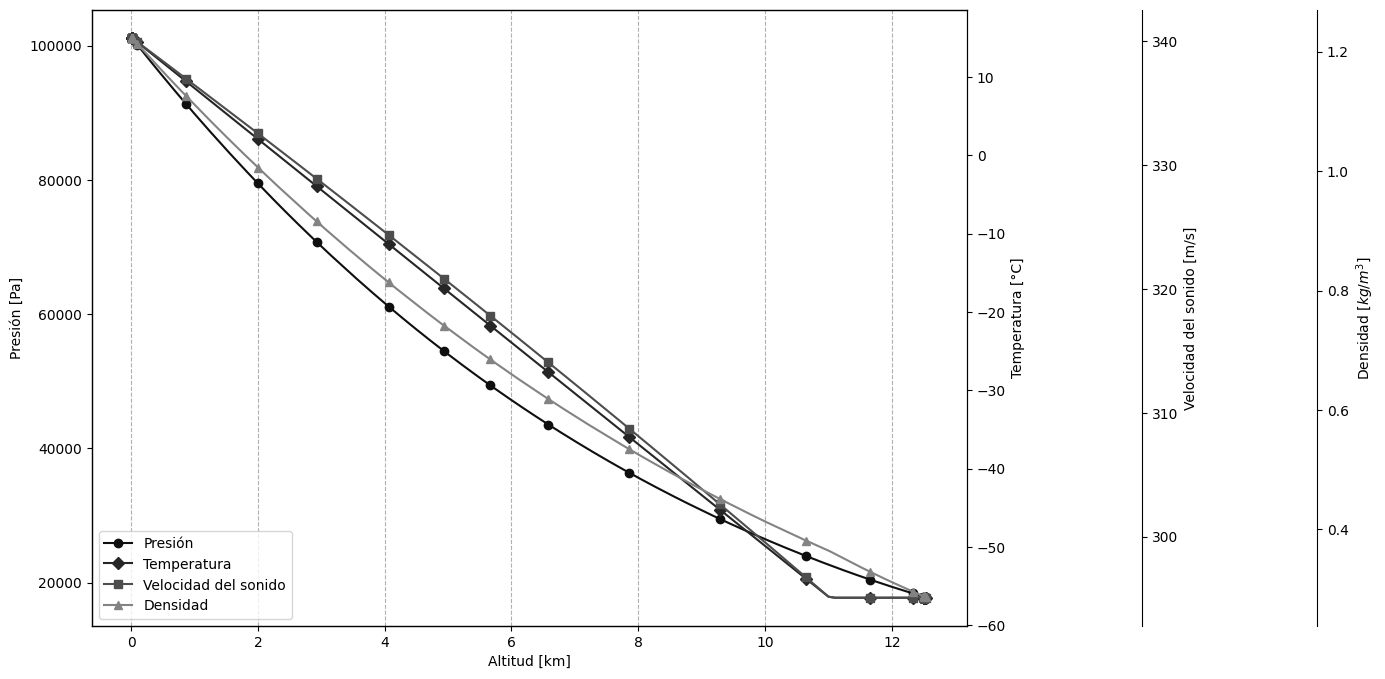

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (14,8)

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, pressure, color='#0F0F0F', label="Presión", marker ="o", markevery=115)
p2, = ax2.plot(altitude, temperature, color='#262626', label="Temperatura", marker ="D", markevery=115)
p3, = ax3.plot(altitude, lightspeed, color='#4D4D4D', label="Velocidad del sonido", marker ="s", markevery=115)
p4, = ax4.plot(altitude, rho, color='#838383', label = 'Densidad', marker ="^", markevery=115)

ax1.set_xlabel("Altitud [km]")
ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")


ax1.grid(linestyle='--', axis='x')
plt.show()


In [33]:
def T(Z):
    if Z<=11: return 15 - 6.5 * Z
    else: return T(11)

def P(Z):
    if Z<=11:
        return 101300 * ((T(Z)+273.15)/288.15)**(9.807/(287*6.5/1000))
    else:
        return P(11) * np.exp(1)**(-9.807 * (Z-11)*10**3 / (287 * (T(11)+273.15)))

def a(Z): return (1.4 * 287 * (T(Z) + 273))**.5

def rho_air(Z): return P(Z)/(287 * (T(Z)+273.15))

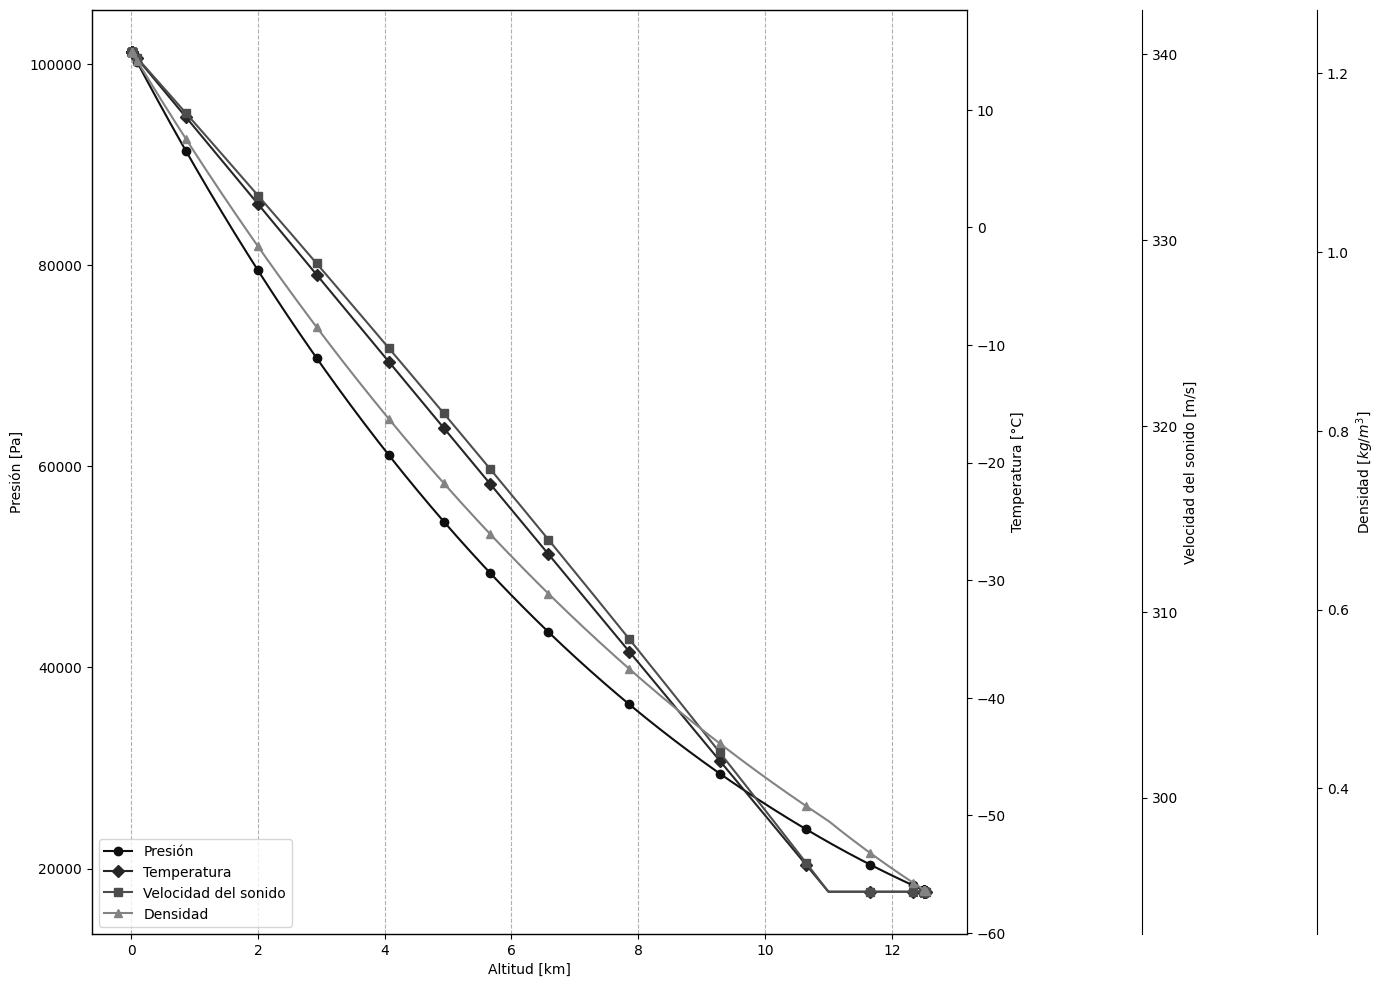

In [34]:
fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (14,8)

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, [P(z) for z in altitude], color="#0F0F0F", label="Presión", marker='o', markevery=115)
p2, = ax2.plot(altitude, [T(z) for z in altitude], color='#262626', label="Temperatura", marker='D', markevery=115)
p3, = ax3.plot(altitude, [a(z) for z in altitude], color="#4D4D4D", label="Velocidad del sonido", marker='s', markevery=115)
p4, = ax4.plot(altitude, [rho_air(z) for z in altitude], color="#838383", label = 'Densidad', marker='^', markevery=115)

ax1.set_xlabel("Altitud [km]")
ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")


ax1.grid(linestyle='--', axis='x')
plt.show()

In [35]:
def error_medio_cuadrado(exper, anal):
    error = 0
    for i in range(len(exper)):
        error += 1/len(exper) * (exper[i]-anal[i])**2
    return error

In [36]:
print('Presión:', (error_medio_cuadrado(pressure, [P(z) for z in altitude]))**.5)
print('Temperatura:', (error_medio_cuadrado(temperature, [T(z) for z in altitude])**.5))
print('Densidad:', (error_medio_cuadrado(rho, [rho_air(z) for z in altitude])**.5))
print('a:', (error_medio_cuadrado(lightspeed, [a(z) for z in altitude])**.5))

Presión: 54.037679807278934
Temperatura: 0.05694576716957092
Densidad: 0.0008709290150243964
a: 0.15215512872364087


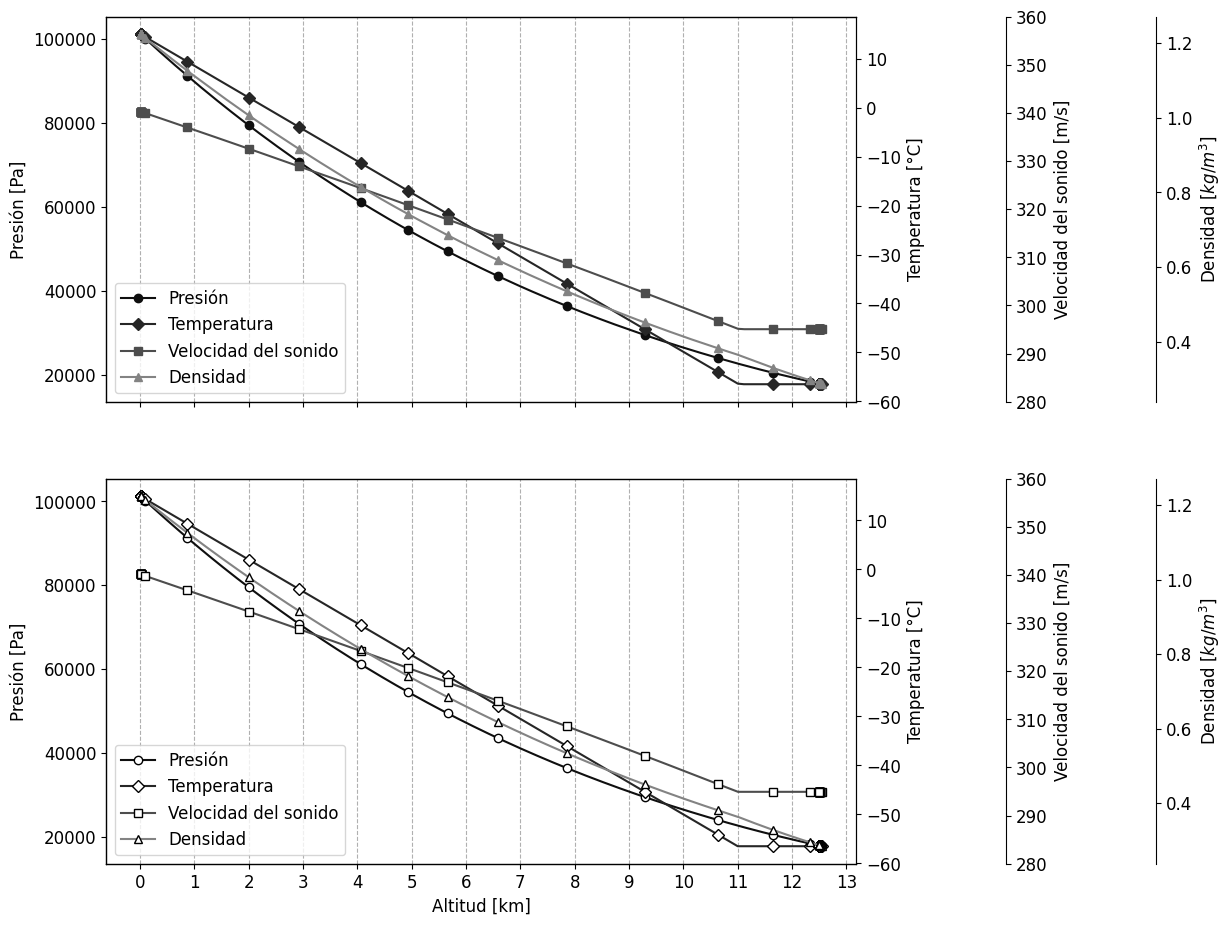

In [81]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax_1) = plt.subplots(2,1, sharex=True)
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (12,11)
plt.rcParams['font.size'] = 12

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, pressure, color='#0F0F0F', label="Presión", marker ="o", markevery=115)
p2, = ax2.plot(altitude, temperature, color='#262626', label="Temperatura", marker ="D", markevery=115)
p3, = ax3.plot(altitude, lightspeed, color='#4D4D4D', label="Velocidad del sonido", marker ="s", markevery=115)
p4, = ax4.plot(altitude, rho, color='#838383', label = 'Densidad', marker ="^", markevery=115)

ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')
ax3.set_ylim([280,360])

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]
ax1.legend(lines, [l.get_label() for l in lines], loc="lower left")

ax_2 = ax_1.twinx()

ax_3 = ax_1.twinx()
ax_3.spines.right.set_position(("axes", 1.20))

ax_4 = ax_1.twinx()
ax_4.spines.right.set_position(("axes", 1.40))

p_1, = ax_1.plot(altitude, [P(z) for z in altitude], color="#0F0F0F", label="Presión", marker='o', markevery=115, markeredgecolor='black', markerfacecolor='white')
p_2, = ax_2.plot(altitude, [T(z) for z in altitude], color='#262626', label="Temperatura", marker='D', markevery=115, markeredgecolor='black', markerfacecolor='white')
p_3, = ax_3.plot(altitude, [a(z) for z in altitude], color="#4D4D4D", label="Velocidad del sonido", marker='s', markevery=115, markeredgecolor='black', markerfacecolor='white')
p_4, = ax_4.plot(altitude, [rho_air(z) for z in altitude], color="#838383", label = 'Densidad', marker='^', markevery=115, markeredgecolor='black', markerfacecolor='white')

ax_1.set_xlabel("Altitud [km]")
ax_1.set_ylabel("Presión [Pa]")
ax_1.tick_params(axis='y')

ax_2.set_ylabel("Temperatura [°C]")
ax_2.tick_params(axis='y')

ax_3.set_ylabel("Velocidad del sonido [m/s]")
ax_3.tick_params(axis='y')
ax_3.set_ylim([280,360])

ax_4.set_ylabel("Densidad $[kg/m^3]$")
ax_4.tick_params(axis='y')

ax_1.legend([p_1, p_2, p_3, p_4], ['Presión', 'Temperatura', 'Velocidad del sonido', 'Densidad'], loc="lower left")

ax1.set_xticks(range(14))
ax1.grid(linestyle='--', axis='x')
ax_1.grid(linestyle='--', axis='x')
plt.show()


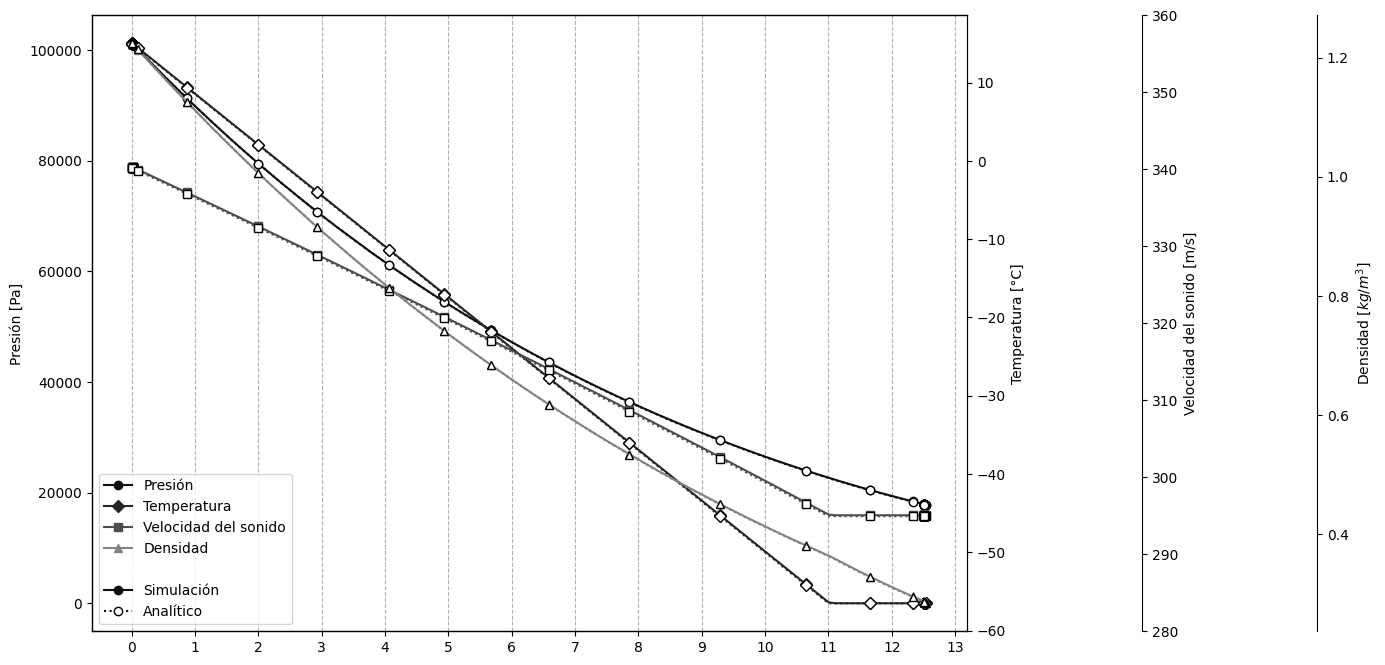

In [74]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax1 = plt.subplots()
fig.subplots_adjust(right=0.75) 
plt.rcParams['figure.figsize'] = (15,8)

ax2 = ax1.twinx()

ax3 = ax1.twinx()
ax3.spines.right.set_position(("axes", 1.20))

ax4 = ax1.twinx()
ax4.spines.right.set_position(("axes", 1.40))

p1, = ax1.plot(altitude, pressure, color='#0F0F0F', label="Presión", marker ="o", markevery=115)
p2, = ax2.plot(altitude, temperature, color='#262626', label="Temperatura", marker ="D", markevery=115)
p3, = ax3.plot(altitude, lightspeed, color='#4D4D4D', label="Velocidad del sonido", marker ="s", markevery=115)
p4, = ax4.plot(altitude, rho, color='#838383', label = 'Densidad', marker ="^", markevery=115)

ax1.set_ylabel("Presión [Pa]")
ax1.tick_params(axis='y')

ax2.set_ylabel("Temperatura [°C]")
ax2.tick_params(axis='y')

ax3.set_ylabel("Velocidad del sonido [m/s]")
ax3.tick_params(axis='y')
ax3.set_ylim([280,360])

ax4.set_ylabel("Densidad $[kg/m^3]$")
ax4.tick_params(axis='y')

lines = [p1, p2, p3, p4]

p_1, = ax1.plot(altitude, [P(z) for z in altitude], color="#0F0F0F", label="Presión",  linestyle=':', marker='o', markevery=115, markerfacecolor='white', markeredgecolor='black')
p_2, = ax2.plot(altitude, [T(z) for z in altitude], color='#262626', label="Temperatura",  linestyle=':', marker='D', markevery=115, markerfacecolor='white', markeredgecolor='black')
p_3, = ax3.plot(altitude, [a(z) for z in altitude], color="#4D4D4D", label="Velocidad del sonido",  linestyle=':', marker='s', markevery=115, markerfacecolor='white', markeredgecolor='black')
p_4, = ax4.plot(altitude, [rho_air(z) for z in altitude], color="#838383", label = 'Densidad', linestyle=':',  marker='^', markevery=115, markerfacecolor='white', markeredgecolor='black')
vacío, = ax1.plot([0],[0], label=' ', color='white')

ax1.legend(lines+[vacío]+[p1, p_1], [l.get_label() for l in lines]+[' ', 'Simulación', 'Analítico'], loc="lower left")
ax1.set_xticks(range(14))
ax1.grid(linestyle='--', axis='x')
ax_1.grid(linestyle='--', axis='x')
plt.show()
